# 04 의사결정

모델 예측 결과를 위험도 3단계로 분류하고,
고위험군 페르소나와 예방 정책 시나리오 4개를 데이터 수치 기반으로 제시한다.

## 섹션 1 — 데이터 및 모델 로드

In [1]:
from pathlib import Path
import sys

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import precision_recall_curve, recall_score

sys.path.append(str(Path('..').resolve()))
from src.preprocessing import ZScoreClipper

matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False

MODEL_DIR = Path('../outputs/models')
best_model = joblib.load(MODEL_DIR / 'best_model.pkl')
preprocessing_pipeline = joblib.load(MODEL_DIR / 'preprocessing_pipeline.pkl')
X_train, X_test, y_train, y_test = joblib.load(MODEL_DIR / 'train_test_split.pkl')

df = pd.read_csv('../data/diabetes_indicators.csv')
X = df.drop('Diabetes_binary', axis=1)
y = df['Diabetes_binary']

feature_names = X.columns.tolist()
X_test_model = pd.DataFrame(X_test, columns=feature_names)

print(f'전체 데이터: {len(df):,}행')
print(f'테스트셋 크기: {len(y_test):,}행')
print('사용 모델: outputs/models/best_model.pkl')
print('사용 전처리기: outputs/models/preprocessing_pipeline.pkl')

전체 데이터: 253,680행
테스트셋 크기: 50,736행
사용 모델: outputs/models/best_model.pkl
사용 전처리기: outputs/models/preprocessing_pipeline.pkl


## 섹션 2 — 위험 점수 산출 및 3단계 분류

위험 단계별 인원:
위험 단계
낮음    24210
중간    13494
높음    13032
Name: count, dtype: int64

위험 단계별 비율:
위험 단계
낮음    0.477
중간    0.266
높음    0.257
Name: proportion, dtype: float64


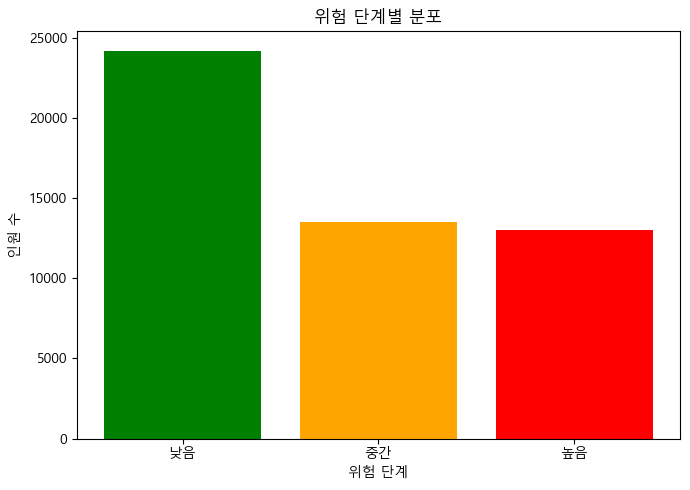

In [2]:
y_prob = best_model.predict_proba(X_test_model)[:, 1]

prob_df = pd.DataFrame({
    'prob': y_prob,
    'actual': y_test.values if hasattr(y_test, 'values') else y_test,
})

def classify_risk(prob):
    if prob >= 0.6:
        return '높음'
    elif prob >= 0.3:
        return '중간'
    return '낮음'

prob_df['risk_tier'] = prob_df['prob'].apply(classify_risk)

tier_counts = prob_df['risk_tier'].value_counts()
tier_ratios = prob_df['risk_tier'].value_counts(normalize=True).round(3)
tier_counts.index.name = '위험 단계'
tier_ratios.index.name = '위험 단계'

print('위험 단계별 인원:')
print(tier_counts)
print('\n위험 단계별 비율:')
print(tier_ratios)

fig, ax = plt.subplots(figsize=(7, 5))
colors = {'낮음': 'green', '중간': 'orange', '높음': 'red'}
for tier in ['낮음', '중간', '높음']:
    count = tier_counts.get(tier, 0)
    ax.bar(tier, count, color=colors[tier])
ax.set_title('위험 단계별 분포')
ax.set_xlabel('위험 단계')
ax.set_ylabel('인원 수')
plt.tight_layout()
plt.savefig('../outputs/figures/04_risk_tiers.png', dpi=150, bbox_inches='tight')
plt.show()

## 섹션 3 — 그룹별 피처 평균 비교

In [3]:
test_indices = y_test.index if hasattr(y_test, 'index') else range(len(y_test))
X_test_df = pd.DataFrame(X_test, columns=feature_names, index=test_indices)
X_test_df['risk_tier'] = prob_df['risk_tier'].values

group_means = X_test_df.groupby('risk_tier').mean().round(3)
group_means.index.name = '위험 단계'
print('그룹별 피처 평균:')
print(group_means.T)

그룹별 피처 평균:
위험 단계                    낮음     높음     중간
HighBP               -0.617  0.891  0.248
HighChol             -0.453  0.644  0.184
CholCheck            -0.164  0.186  0.138
BMI                  -0.429  0.717  0.089
Smoker               -0.144  0.205  0.072
Stroke               -0.163  0.350 -0.031
HeartDiseaseorAttack -0.274  0.572 -0.066
PhysActivity          0.210 -0.379 -0.030
Fruits                0.078 -0.123 -0.028
Veggies               0.104 -0.169 -0.024
HvyAlcoholConsump     0.151 -0.184 -0.055
AnyHealthcare        -0.043  0.043  0.027
NoDocbcCost          -0.056  0.102 -0.028
GenHlth              -0.589  0.957  0.125
MentHlth             -0.094  0.177 -0.016
PhysHlth             -0.271  0.502 -0.018
DiffWalk             -0.344  0.677 -0.033
Sex                  -0.095  0.087  0.061
Age                  -0.498  0.599  0.310
Education             0.248 -0.398 -0.050
Income                0.304 -0.507 -0.027


## 고위험군 페르소나

**"당뇨 고위험 프로파일"**

| 항목 | 고위험군 평균(표준화) | 저위험군 평균(표준화) |
|------|----------------------|----------------------|
| BMI | 0.717 | -0.429 |
| HighBP | 0.891 | -0.617 |
| PhysActivity | -0.379 | 0.210 |
| Age | 0.599 | -0.498 |
| GenHlth | 0.957 | -0.589 |

→ 대표 페르소나: 표준화 기준 BMI·GenHlth 높음, 신체 활동 부족, 고혈압 해당

## 섹션 4 — 정책 시나리오

In [4]:
batch_size = 50000
all_probs = []
for i in range(0, len(X), batch_size):
    batch = X.iloc[i:i + batch_size]
    batch_processed = preprocessing_pipeline.transform(batch)
    batch_model = pd.DataFrame(batch_processed, columns=feature_names, index=batch.index)
    probs = best_model.predict_proba(batch_model)[:, 1]
    all_probs.extend(probs)

df['risk_prob'] = all_probs
df['risk_tier'] = pd.cut(
    df['risk_prob'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['낮음', '중간', '높음'],
    include_lowest=True,
)

total = len(df)
scenario_rows = [
    {
        '시나리오': 'A',
        '대상': '고위험군 전체',
        '개입 방식': '정기 혈당 검사 의무화',
        '대상 인원': int((df['risk_tier'] == '높음').sum()),
    },
    {
        '시나리오': 'B',
        '대상': 'BMI >= 30 + 고위험',
        '개입 방식': '체중 관리 프로그램 연계',
        '대상 인원': int(((df['risk_tier'] == '높음') & (df['BMI'] >= 30)).sum()),
    },
    {
        '시나리오': 'C',
        '대상': '운동 부족 + 중/고위험',
        '개입 방식': '지역 운동 프로그램 무료 제공',
        '대상 인원': int(((df['risk_tier'].isin(['중간', '높음'])) & (df['PhysActivity'] == 0)).sum()),
    },
    {
        '시나리오': 'D',
        '대상': '흡연+고혈압 복합 + 중/고위험',
        '개입 방식': '금연·혈압 관리 패키지',
        '대상 인원': int(((df['risk_tier'].isin(['중간', '높음'])) & (df['Smoker'] == 1) & (df['HighBP'] == 1)).sum()),
    },
]
scenario_summary = pd.DataFrame(scenario_rows)
scenario_summary['비율'] = (scenario_summary['대상 인원'] / total).map(lambda value: f'{value:.1%}')

print('시나리오별 정책 대상:')
display(scenario_summary)

시나리오별 정책 대상:


,시나리오,대상,개입 방식,대상 인원,비율
0,A,고위험군 전체,정기 혈당 검사 의무화,65035,25.6%
1,B,BMI >= 30 + 고위험,체중 관리 프로그램 연계,40936,16.1%
2,C,운동 부족 + 중/고위험,지역 운동 프로그램 무료 제공,43391,17.1%
3,D,흡연+고혈압 복합 + 중/고위험,금연·혈압 관리 패키지,48031,18.9%


## 시나리오별 정책 대상

위 표는 01번 전처리에서 저장한 추론용 전처리기를 동일하게 적용한 결과다.
표의 대상 인원과 비율은 위 코드 실행 결과에서 자동으로 계산된다.

## 섹션 5 — 임계값 트레이드오프

기본 임계값 Recall: 0.761
F1 최대 임계값: 0.609
Recall >= 0.8 보장 임계값: 0.460


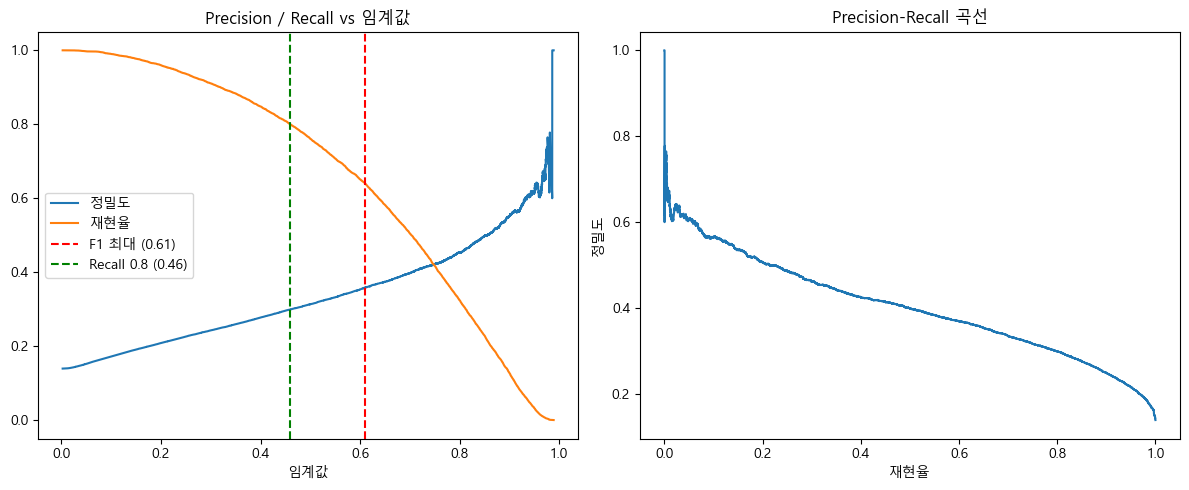

In [5]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_f1_thresh = thresholds[np.argmax(f1_scores[:-1])]
recall_80_idx = np.where(recall[:-1] >= 0.8)[0]
recall_80_thresh = thresholds[recall_80_idx[-1]] if len(recall_80_idx) > 0 else None
model_recall = recall_score(y_test, best_model.predict(X_test_model))

print(f'기본 임계값 Recall: {model_recall:.3f}')
print(f'F1 최대 임계값: {best_f1_thresh:.3f}')
print(f'Recall >= 0.8 보장 임계값: {recall_80_thresh:.3f}' if recall_80_thresh is not None else 'Recall 0.8 달성 임계값 없음')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(thresholds, precision[:-1], label='정밀도')
axes[0].plot(thresholds, recall[:-1], label='재현율')
axes[0].axvline(x=best_f1_thresh, color='red', linestyle='--', label=f'F1 최대 ({best_f1_thresh:.2f})')
if recall_80_thresh is not None:
    axes[0].axvline(x=recall_80_thresh, color='green', linestyle='--', label=f'Recall 0.8 ({recall_80_thresh:.2f})')
axes[0].set_xlabel('임계값')
axes[0].set_title('Precision / Recall vs 임계값')
axes[0].legend()

axes[1].plot(recall[:-1], precision[:-1])
axes[1].set_xlabel('재현율')
axes[1].set_ylabel('정밀도')
axes[1].set_title('Precision-Recall 곡선')

plt.tight_layout()
plt.savefig('../outputs/figures/04_threshold_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

## 조기 개입 효과 추정

- 전체 데이터에 대해 저장된 전처리기와 모델을 동일하게 적용해 위험군을 분류했다.
- 기본 임계값 Recall 값을 확인하고, Recall 0.8 달성을 위한 임계값을 비교했다.
- Recall을 높이면 더 많은 위험군을 찾을 수 있지만 Precision은 낮아진다.

→ **권장 기준**: 당뇨 미탐지 비용이 오탐지 비용보다 크므로 Recall 중심 임계값을 우선한다.